- importando as bibliotecas 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
sns.set(style="whitegrid")

In [2]:
conn = sqlite3.connect("data/database.sqlite")

In [3]:

dados = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)



In [4]:

matches = pd.read_sql("SELECT * FROM Match;", conn)

matches.shape
matches.head()


,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,...,SJA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA
0,1,1,1,2008/2009,1,2008-08-17 00:00:00,492473,9987,9993,1,...,4.00,1.65,3.40,4.50,1.78,3.25,4.00,1.73,3.40,4.20
1,2,1,1,2008/2009,1,2008-08-16 00:00:00,492474,10000,9994,0,...,3.80,2.00,3.25,3.25,1.85,3.25,3.75,1.91,3.25,3.60
2,3,1,1,2008/2009,1,2008-08-16 00:00:00,492475,9984,8635,0,...,2.50,2.35,3.25,2.65,2.50,3.20,2.50,2.30,3.20,2.75
3,4,1,1,2008/2009,1,2008-08-17 00:00:00,492476,9991,9998,5,...,7.50,1.45,3.75,6.50,1.50,3.75,5.50,1.44,3.75,6.50
4,5,1,1,2008/2009,1,2008-08-16 00:00:00,492477,7947,9985,1,...,1.73,4.50,3.40,1.65,4.50,3.50,1.65,4.75,3.30,1.67


- Entendendo a estrutura da tabela Match

In [5]:
matches.columns

Index(['id', 'country_id', 'league_id', 'season', 'stage', 'date',
       'match_api_id', 'home_team_api_id', 'away_team_api_id',
       'home_team_goal',
       ...
       'SJA', 'VCH', 'VCD', 'VCA', 'GBH', 'GBD', 'GBA', 'BSH', 'BSD', 'BSA'],
      dtype='str', length=115)

In [6]:
# Subconjunto de colunas para análise das partidas
partidas_eda = matches[
    [
        "season",
        "date",
        "home_team_api_id",
        "away_team_api_id",
        "home_team_goal",
        "away_team_goal"
    ]
].copy()

partidas_eda


,season,date,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal
0,2008/2009,2008-08-17 00:00:00,9987,9993,1,1
1,2008/2009,2008-08-16 00:00:00,10000,9994,0,0
2,2008/2009,2008-08-16 00:00:00,9984,8635,0,3
3,2008/2009,2008-08-17 00:00:00,9991,9998,5,0
4,2008/2009,2008-08-16 00:00:00,7947,9985,1,3
...,...,...,...,...,...,...
25974,2015/2016,2015-09-22 00:00:00,10190,10191,1,0
25975,2015/2016,2015-09-23 00:00:00,9824,10199,1,2
25976,2015/2016,2015-09-23 00:00:00,9956,10179,2,0
25977,2015/2016,2015-09-22 00:00:00,7896,10243,0,0


In [7]:
# conferindo valores unicos
partidas_eda.info()

<class 'pandas.DataFrame'>
RangeIndex: 25979 entries, 0 to 25978
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   season            25979 non-null  str  
 1   date              25979 non-null  str  
 2   home_team_api_id  25979 non-null  int64
 3   away_team_api_id  25979 non-null  int64
 4   home_team_goal    25979 non-null  int64
 5   away_team_goal    25979 non-null  int64
dtypes: int64(4), str(2)
memory usage: 1.2 MB


In [8]:
#Converter a coluna de data
partidas_eda['date'] = pd.to_datetime(partidas_eda['date'])
partidas_eda["ano"] = partidas_eda["date"].dt.year

- Gols totais das partidas

In [9]:
partidas_eda['gols_totais'] = (
    partidas_eda['home_team_goal'] +
    partidas_eda['away_team_goal']
)


Resultado das partidas

In [10]:
def resultado_partida(linha):
    if linha['home_team_goal'] > linha['away_team_goal']:
        return 'Vitoria mandante'
    elif linha['home_team_goal'] < linha['away_team_goal']:
        return 'Vitoria visitante'
    else:
        return 'Empate'
    

partidas_eda["resultado"] = partidas_eda.apply(
    resultado_partida, axis=1
)


In [11]:
partidas_eda.head()

,season,date,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal,ano,gols_totais,resultado
0,2008/2009,2008-08-17,9987,9993,1,1,2008,2,Empate
1,2008/2009,2008-08-16,10000,9994,0,0,2008,0,Empate
2,2008/2009,2008-08-16,9984,8635,0,3,2008,3,Vitoria visitante
3,2008/2009,2008-08-17,9991,9998,5,0,2008,5,Vitoria mandante
4,2008/2009,2008-08-16,7947,9985,1,3,2008,4,Vitoria visitante


Distribuindo gols por partidas

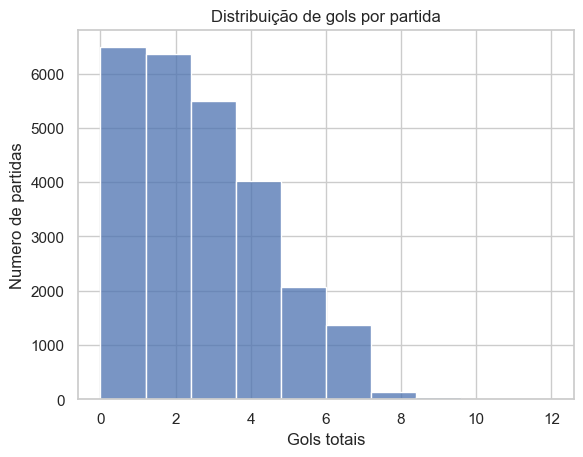

In [12]:
sns.histplot(partidas_eda['gols_totais'], bins=10)
plt.title('Distribuição de gols por partida')
plt.xlabel('Gols totais')
plt.ylabel('Numero de partidas')
plt.show()

Distribuindo Resultados

In [13]:
partidas_eda['resultado'].value_counts(normalize= True)

resultado
Vitoria mandante     0.458717
Vitoria visitante    0.287386
Empate               0.253897
Name: proportion, dtype: float64

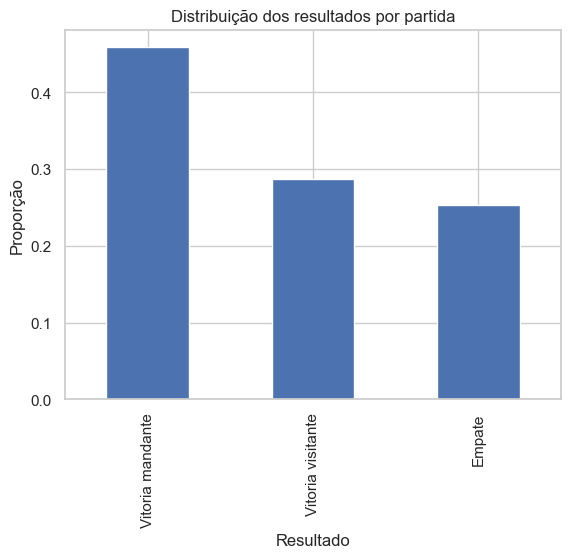

In [14]:
partidas_eda['resultado'].value_counts(
    normalize= True).plot(kind='bar')

plt.title('Distribuição dos resultados por partida')
plt.ylabel('Proporção')
plt.xlabel('Resultado')
plt.show()


In [15]:

partidas_eda = partidas_eda.rename(columns={
    "home_team_goal": "gols_mandante",
    "away_team_goal": "gols_visitante"
})


Mandante x Visitante gols

In [16]:
# Vendo quantos gols cada lado fez
partidas_eda[['gols_mandante', 'gols_visitante']].describe()

,gols_mandante,gols_visitante
count,25979.000000,25979.000000
mean,1.544594,1.160938
std,1.297158,1.142110
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,10.000000,9.000000


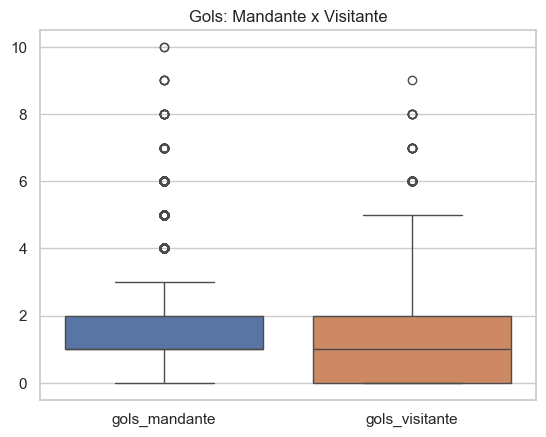

In [17]:
# comparando
sns.boxplot(
    data=partidas_eda[['gols_mandante', 'gols_visitante']]
)
plt.title('Gols: Mandante x Visitante')
plt.show()

Analise temporal

In [18]:
# media de gols por temporada
media_gols_temporada = (
    partidas_eda.groupby('season')['gols_totais'].mean()
)
media_gols_temporada

season
2008/2009    2.607336
2009/2010    2.672446
2010/2011    2.683742
2011/2012    2.716460
2012/2013    2.772699
2013/2014    2.766821
2014/2015    2.675789
2015/2016    2.754660
Name: gols_totais, dtype: float64

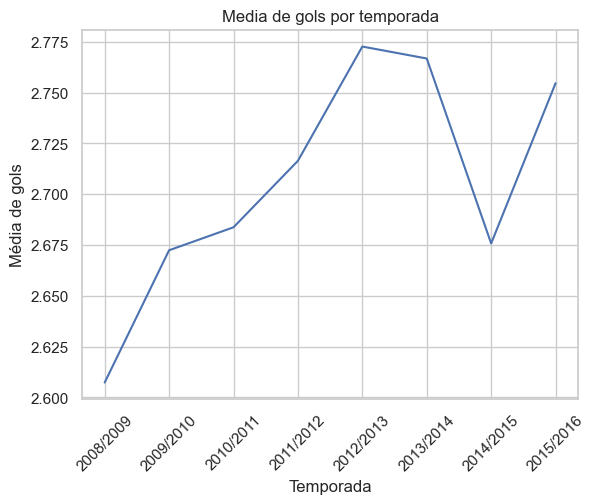

In [19]:
sns.lineplot(
    x=media_gols_temporada.index,
    y=media_gols_temporada.values
)
plt.title('Media de gols por temporada')
plt.xlabel('Temporada')
plt.ylabel('Média de gols')
plt.xticks(rotation=45)
plt.show()

Tabela de times

In [20]:
times = pd.read_sql("SELECT team_api_id, team_long_name FROM Team;",
                    conn)
times.head

<bound method NDFrame.head of      team_api_id      team_long_name
0           9987            KRC Genk
1           9993        Beerschot AC
2          10000    SV Zulte-Waregem
3           9994    Sporting Lokeren
4           9984   KSV Cercle Brugge
..           ...                 ...
294        10190       FC St. Gallen
295        10191             FC Thun
296         9777         Servette FC
297         7730  FC Lausanne-Sports
298         7896              Lugano

[299 rows x 2 columns]>

Mandante

In [21]:
partidas_times = partidas_eda.merge(
    times,
    left_on='home_team_api_id',
    right_on='team_api_id',
    how='left'
)

partidas_times = partidas_times.rename(columns={
    "team_long_name": "time_mandante"
})

partidas_times.head()

,season,date,home_team_api_id,away_team_api_id,gols_mandante,gols_visitante,ano,gols_totais,resultado,team_api_id,time_mandante
0,2008/2009,2008-08-17,9987,9993,1,1,2008,2,Empate,9987,KRC Genk
1,2008/2009,2008-08-16,10000,9994,0,0,2008,0,Empate,10000,SV Zulte-Waregem
2,2008/2009,2008-08-16,9984,8635,0,3,2008,3,Vitoria visitante,9984,KSV Cercle Brugge
3,2008/2009,2008-08-17,9991,9998,5,0,2008,5,Vitoria mandante,9991,KAA Gent
4,2008/2009,2008-08-16,7947,9985,1,3,2008,4,Vitoria visitante,7947,FCV Dender EH


Visitante

In [22]:

partidas_times = partidas_times.merge(
    times,
    left_on="away_team_api_id",
    right_on="team_api_id",
    how="left"
)

partidas_times = partidas_times.rename(columns={
    "team_long_name": "time_visitante"
})
partidas_times.head()

,season,date,home_team_api_id,away_team_api_id,gols_mandante,gols_visitante,ano,gols_totais,resultado,team_api_id_x,time_mandante,team_api_id_y,time_visitante
0,2008/2009,2008-08-17,9987,9993,1,1,2008,2,Empate,9987,KRC Genk,9993,Beerschot AC
1,2008/2009,2008-08-16,10000,9994,0,0,2008,0,Empate,10000,SV Zulte-Waregem,9994,Sporting Lokeren
2,2008/2009,2008-08-16,9984,8635,0,3,2008,3,Vitoria visitante,9984,KSV Cercle Brugge,8635,RSC Anderlecht
3,2008/2009,2008-08-17,9991,9998,5,0,2008,5,Vitoria mandante,9991,KAA Gent,9998,RAEC Mons
4,2008/2009,2008-08-16,7947,9985,1,3,2008,4,Vitoria visitante,7947,FCV Dender EH,9985,Standard de Liège


Gols marcados como mandante 

In [23]:
gols_mandante = (
    partidas_times.groupby('time_mandante')['gols_mandante'].sum().sort_values(ascending= False)
)
gols_mandante.head(10)

time_mandante
Real Madrid CF       505
FC Barcelona         495
Celtic               389
FC Bayern Munich     382
PSV                  370
Manchester City      365
Ajax                 360
FC Basel             344
Manchester United    338
Chelsea              333
Name: gols_mandante, dtype: int64

Gols sofridos como mandante

In [24]:
gols_sofridos_mandante = (partidas_times.groupby('time_mandante')['gols_visitante'].sum().sort_values()
)
gols_sofridos_mandante.head(10)

time_mandante
Amadora                         15
Angers SCO                      15
Uniao da Madeira                17
UD Las Palmas                   17
FC Ingolstadt 04                18
Watford                         19
Feirense                        19
Termalica Bruk-Bet Nieciecza    19
Middlesbrough                   20
Trofense                        21
Name: gols_visitante, dtype: int64

Saldo de gols como Mandante

In [25]:
ranking_mandante = (
    partidas_times.groupby('time_mandante')[['gols_mandante', 'gols_visitante']].sum())

ranking_mandante['saldo_gols_mandante'] = (
    ranking_mandante['gols_mandante'] - ranking_mandante['gols_visitante']
)

ranking_mandante.sort_values('saldo_gols_mandante', ascending=False).head()

,gols_mandante,gols_visitante,saldo_gols_mandante
time_mandante,,,
FC Barcelona,495,101,394
Real Madrid CF,505,147,358
Celtic,389,88,301
FC Bayern Munich,382,96,286
Ajax,360,78,282



### Conclusão Parcial

Nesta etapa foi realizada a análise exploratória inicial da base de dados,
com foco nas partidas e no desempenho dos times atuando como mandantes.
Foram identificados padrões de distribuição de gols, vantagem do mandante
e diferenças claras entre desempenho ofensivo e defensivo dos times.



- Análise dos times: força ofensiva e defensiva

Gols como mandante

In [30]:

gols_marcados_casa = (
    partidas_times.groupby('time_mandante')['gols_mandante']
    .sum()
)
gols_marcados_casa 


time_mandante
1. FC Kaiserslautern         37
1. FC Köln                  116
1. FC Nürnberg              108
1. FSV Mainz 05             171
AC Ajaccio                   64
                           ... 
Xerez Club Deportivo         20
Zagłębie Lubin              116
Zawisza Bydgoszcz            43
Évian Thonon Gaillard FC    105
Śląsk Wrocław               176
Name: gols_mandante, Length: 296, dtype: int64

- CRIANDO VITORIA COMO VARIAVEIS NUMERICAS

In [36]:
partidas_times['vitoria_mandante'] = (
    partidas_times['resultado'] == 'Vitoria mandante'
)

partidas_times['vitoria_visitante'] = (
    partidas_times['resultado'] == 'Vitoria visitante'
)

-  Vitórias como mandante

In [37]:
vitoria_mandante = (partidas_times.groupby('time_mandante')['vitoria_mandante']
                    .sum().sort_values(ascending=False))

vitoria_mandante.head(10)

time_mandante
FC Barcelona         131
Real Madrid CF       129
Celtic               120
Manchester United    116
Manchester City      113
FC Bayern Munich     109
PSV                  105
Juventus             105
Ajax                 103
FC Basel             103
Name: vitoria_mandante, dtype: int64

- Vitorias como visitantes

In [38]:
vitoria_visitante = (partidas_times.groupby('time_visitante')['vitoria_visitante']
                     .sum().sort_values(ascending=False))

vitoria_visitante.head(10)


time_visitante
FC Barcelona         103
Real Madrid CF        99
Celtic                98
Juventus              84
FC Bayern Munich      84
SL Benfica            83
FC Porto              81
Ajax                  78
FC Basel              77
Manchester United     76
Name: vitoria_visitante, dtype: int64

### Força Ofensiva

- Media de gols por time em casa e fora

In [42]:
gols_casa = partidas_times.groupby('time_mandante')['gols_mandante'].mean()
gols_fora = partidas_times.groupby('time_visitante')['gols_visitante'].mean()

media_gols_time = (gols_casa + gols_fora) / 2

media_gols_time = media_gols_time.sort_values(ascending=False)

media_gols_time.head(10)

time_mandante
FC Barcelona        2.792763
Real Madrid CF      2.773026
FC Bayern Munich    2.400735
PSV                 2.397059
Ajax                2.378676
SL Benfica          2.290323
Celtic              2.286184
FC Porto            2.181452
FC Basel            2.164336
Rangers             2.131579
dtype: float64

### Força Defensiva

In [45]:
gols_sofridos_casa = partidas_times.groupby('time_mandante')['gols_mandante'].mean()
gols_sofridos_fora = partidas_times.groupby('time_visitante')['gols_visitante'].mean()

media_gols_sofridos = (gols_sofridos_casa + gols_sofridos_fora) / 2
media_gols_sofridos = media_gols_sofridos.sort_values()
media_gols_sofridos.head(10)

time_mandante
AC Arles-Avignon        0.552632
Córdoba CF              0.578947
FC Dordrecht            0.705882
Pescara                 0.710526
Grenoble Foot 38        0.723684
Middlesbrough           0.736842
Boavista FC             0.750000
SpVgg Greuther Fürth    0.764706
Naval 1° de Maio        0.788889
Le Havre AC             0.789474
dtype: float64

### Criando Métrica complete

In [59]:

mandante = partidas_times[['time_mandante', 'gols_mandante', 'gols_visitante']].copy()

mandante.columns = ['time', 'gols_feitos', 'gols_sofridos']

visitante = partidas_times[['time_visitante', 'gols_visitante', 'gols_mandante']].copy()

visitante.columns = ['time', 'gols_feitos', 'gols_sofridos']


- junta Ataque + Defesa

In [54]:

desempenho_times = dados_times.groupby('time').agg({
    'gols_feitos': 'mean',
    'gols_sofridos': 'mean'
})


- Saldo médio

In [55]:
desempenho_times['saldo_medio'] = (
    desempenho_times['gols_feitos'] -
    desempenho_times['gols_sofridos']
)

desempenho_times = desempenho_times.sort_values(by='saldo_medio', ascending=False)

desempenho_times.head(10)

,gols_feitos,gols_sofridos,saldo_medio
time,,,
FC Barcelona,2.792763,0.763158,2.029605
Real Madrid CF,2.773026,1.000000,1.773026
FC Bayern Munich,2.400735,0.775735,1.625000
Celtic,2.286184,0.733553,1.552632
SL Benfica,2.290323,0.750000,1.540323
FC Porto,2.181452,0.649194,1.532258
Ajax,2.378676,0.867647,1.511029
Rangers,2.131579,0.743421,1.388158
PSV,2.397059,1.080882,1.316176


Text(0, 0.5, 'Gols marcados (maior = melhor ataque)')

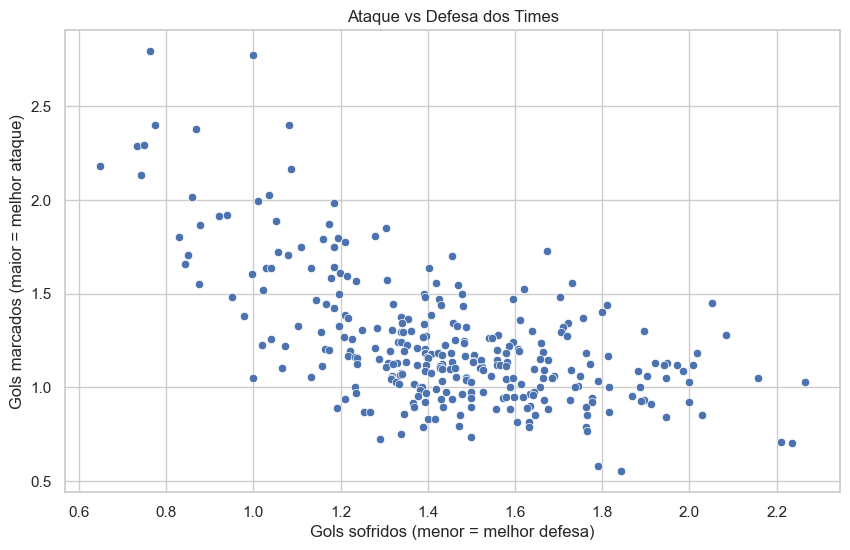

In [61]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=desempenho_times,
    x='gols_sofridos',
    y='gols_feitos'
)


plt.title('Ataque vs Defesa dos Times')
plt.xlabel('Gols sofridos (menor = melhor defesa)')
plt.ylabel('Gols marcados (maior = melhor ataque)')


- top 10 melhores

In [62]:

melhores_times = desempenho_times.sort_values(
    by='saldo_medio',
    ascending=False
)

melhores_times.head(10)


,gols_feitos,gols_sofridos,saldo_medio
time,,,
FC Barcelona,2.792763,0.763158,2.029605
Real Madrid CF,2.773026,1.000000,1.773026
FC Bayern Munich,2.400735,0.775735,1.625000
Celtic,2.286184,0.733553,1.552632
SL Benfica,2.290323,0.750000,1.540323
FC Porto,2.181452,0.649194,1.532258
Ajax,2.378676,0.867647,1.511029
Rangers,2.131579,0.743421,1.388158
PSV,2.397059,1.080882,1.316176


- Top 10 piores

In [63]:

piores_times = desempenho_times.sort_values(
    by='saldo_medio',
    ascending=True
)

piores_times.head(10)


,gols_feitos,gols_sofridos,saldo_medio
time,,,
FC Dordrecht,0.705882,2.235294,-1.529412
Pescara,0.710526,2.210526,-1.500000
AC Arles-Avignon,0.552632,1.842105,-1.289474
Tubize,1.029412,2.264706,-1.235294
Córdoba CF,0.578947,1.789474,-1.210526
FC Penafiel,0.852941,2.029412,-1.176471
Dunfermline Athletic,1.052632,2.157895,-1.105263
Cardiff City,0.842105,1.947368,-1.105263
Frosinone,0.921053,2.000000,-1.078947
